# **Intro Data**

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Realestate.csv')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
df['X1 transaction date']=df['X1 transaction date'].astype(int)

In [ ]:
new_names = ['No','date','age','dist','store','lat','long','price']
df = df.set_axis(new_names, axis="columns")

In [ ]:
df.set_index('No')

,date,age,dist,store,lat,long,price
No,,,,,,,
1,2012,32.0,84.87882,10,24.98298,121.54024,37.9
2,2012,19.5,306.59470,9,24.98034,121.53951,42.2
3,2013,13.3,561.98450,5,24.98746,121.54391,47.3
4,2013,13.3,561.98450,5,24.98746,121.54391,54.8
5,2012,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...
410,2013,13.7,4082.01500,0,24.94155,121.50381,15.4
411,2012,5.6,90.45606,9,24.97433,121.54310,50.0
412,2013,18.8,390.96960,7,24.97923,121.53986,40.6


In [ ]:
dups=df.duplicated()
print(dups.any())

False


In [ ]:
Q1 = df.dist.quantile(0.25)
Q3 = df.dist.quantile(0.75)
IQR = Q3 - Q1
df_1 = df[~((df.dist < (Q1 - 1.5 * IQR)) | (df.dist > (Q3 +1.5 *IQR)))]
print(df.shape)
print(df_1.shape)

(414, 8)
(377, 8)


In [ ]:
Q1 = df_1.lat.quantile(0.25)
Q3 = df_1.lat.quantile(0.75)
IQR = Q3 - Q1
df_2 = df_1[~((df_1.lat < (Q1 - 1.5 * IQR)) | (df_1.lat > (Q3 + 1.5 * IQR)))]
print(df_1.shape)
print(df_2.shape)

(377, 8)
(376, 8)


In [ ]:
Q1 = df_2.long.quantile(0.25)
Q3 = df_2.long.quantile(0.75)
IQR = Q3 - Q1
df_3 = df_2[~((df_2.long < (Q1 - 1.5 * IQR)) | (df_2.long > (Q3 + 1.5 * IQR)))]
print(df_2.shape)
print(df_3.shape)

(376, 8)
(315, 8)


In [ ]:
Q1 = df_3.price.quantile(0.25)
Q3 = df_3.price.quantile(0.75)
IQR = Q3 - Q1
df_4 = df_3[~((df_3.price < (Q1 - 1.5 * IQR)) | (df_3.price > (Q3 + 1.5 * IQR)))]
print(df_3.shape)
print(df_4.shape)

(315, 8)
(303, 8)


In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_5 = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
print(df.shape)
print(df_5.shape)

(414, 8)
(371, 8)


<ipython-input-12-67204027714b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_4['trans_dist'] =  np.log(df_4.dist.copy())
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


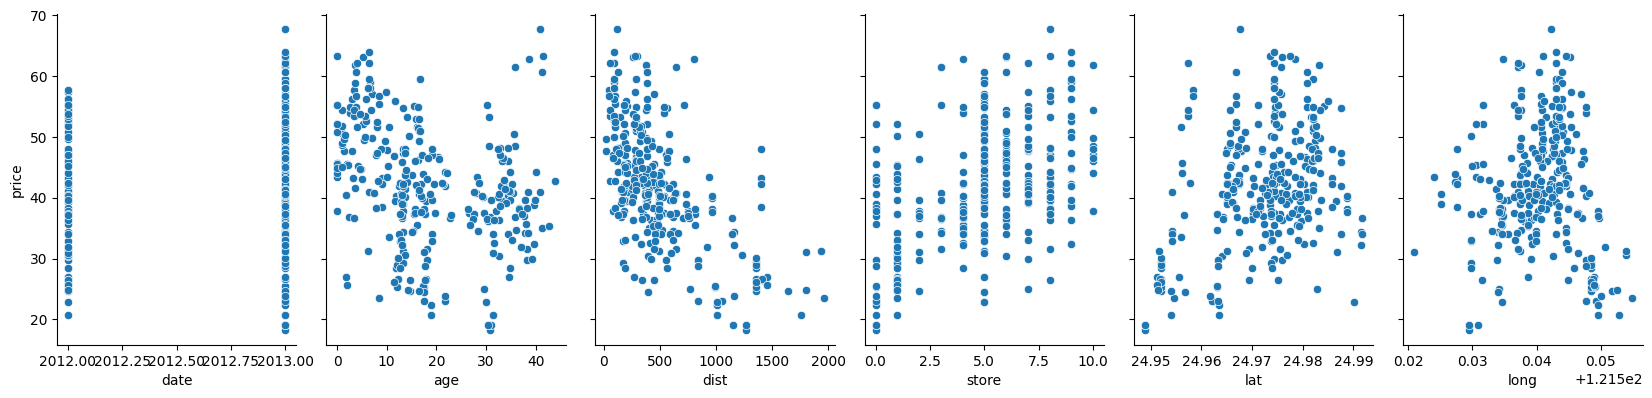

In [ ]:
df_4['trans_dist'] =  np.log(df_4.dist.copy())
p = sns.pairplot(df_4, x_vars=['date', 'age', 'dist', 'store',
       'lat', 'long'], y_vars= 'price', size=4, aspect=0.7)

In [ ]:
df.columns

Index(['No', 'date', 'age', 'dist', 'store', 'lat', 'long', 'price'], dtype='object')

# **MLP_df**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      414 non-null    int64  
 1   date    414 non-null    int64  
 2   age     414 non-null    float64
 3   dist    414 non-null    float64
 4   store   414 non-null    int64  
 5   lat     414 non-null    float64
 6   long    414 non-null    float64
 7   price   414 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 26.0 KB

Membuat neural network dengan aktivasi relu
Mean Squared Error: 131.89250800466274
Mean Absolute Error: 6.836805914245711
R-squared Score: 0.4683578468447177



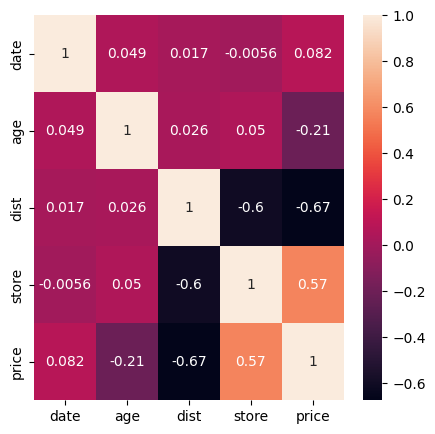

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

df.info()
corr = df.drop(['No','lat','long'],axis=1).corr()
plt.subplots(figsize = (5,5))
sns.heatmap(corr, annot = True)

# Bagi data Anda menjadi set pelatihan dan pengujian
X = df.drop(['No','price','lat','long'],axis=1)
Y = df.iloc[:,-1]
sc=StandardScaler()
X=sc.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Tentukan parameter hiperparameter jaringan saraf Anda
params = {
    'hidden_layer_sizes': (3,2),  # Sesuaikan jumlah neuron di setiap lapisan tersembunyi
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.0001,  # Kekuatan regularisasi
    'batch_size': 10,
    'random_state': 0,
    'tol': 1e-4,
    'momentum': 0.9,  # Momentum
    'learning_rate': 'constant',
    'learning_rate_init': 0.01,
    'max_iter': 500,
    'shuffle': True,
    'n_iter_no_change': 50,
    'verbose': False
}

# Buat MLPRegressor
print("\nMembuat neural network dengan aktivasi relu")
net = MLPRegressor(**params)

# Latih NN pada data training
net.fit(X_train, Y_train)

# Lakukan prediksi pada data test
Y_pred_net = net.predict(X_test)

# Evaluasi kinerja model
mse = mean_squared_error(Y_test, Y_pred_net)
mae = mean_absolute_error(Y_test, Y_pred_net)
r2 = r2_score(Y_test, Y_pred_net)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared Score: {r2}\n")

In [ ]:
pred_df=pd.DataFrame({'Actual Value':Y_test,'Predicted Value':Y_pred_net,'Difference':Y_test-Y_pred_net})
pred_df

,Actual Value,Predicted Value,Difference
276,34.0,41.630702,-7.630702
229,19.0,27.403315,-8.403315
112,23.1,27.664191,-4.564191
63,55.0,47.128899,7.871101
268,40.1,42.395716,-2.295716
...,...,...,...
76,36.8,38.438511,-1.638511
345,37.9,43.665404,-5.765404
148,45.1,19.540864,25.559136
28,47.0,39.675083,7.324917


# **MLP_df5**

<class 'pandas.core.frame.DataFrame'>
Int64Index: 371 entries, 0 to 413
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      371 non-null    int64  
 1   date    371 non-null    int64  
 2   age     371 non-null    float64
 3   dist    371 non-null    float64
 4   store   371 non-null    int64  
 5   lat     371 non-null    float64
 6   long    371 non-null    float64
 7   price   371 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 26.1 KB

Membuat neural network dengan aktivasi relu
Mean Squared Error: 59.193435142299506
Mean Absolute Error: 5.663347963817013
R-squared Score: 0.5509383399423731



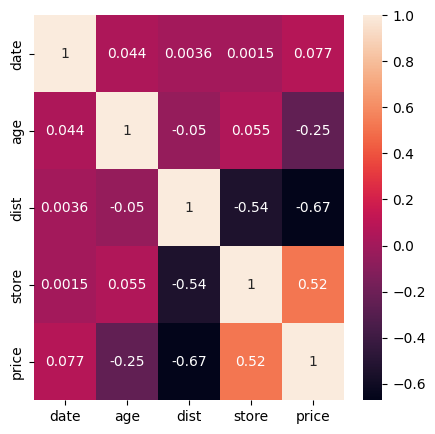

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

df_5.info()
corr = df_5.drop(['No','lat','long'],axis=1).corr()
plt.subplots(figsize = (5,5))
sns.heatmap(corr, annot = True)

# Bagi data Anda menjadi set pelatihan dan pengujian
X = df_5.drop(['No','price','lat','long'],axis=1)
Y = df_5.iloc[:,-1]
sc=StandardScaler()
X=sc.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Tentukan parameter hiperparameter jaringan saraf Anda
params = {
    'hidden_layer_sizes': (10,2),  # Sesuaikan jumlah neuron di setiap lapisan tersembunyi
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.0001,  # Kekuatan regularisasi
    'batch_size': 10,
    'random_state': 0,
    'tol': 1e-4,
    'momentum': 0.9,  # Momentum
    'learning_rate': 'constant',
    'learning_rate_init': 0.01,
    'max_iter': 500,
    'shuffle': True,
    'n_iter_no_change': 50,
    'verbose': False
}

# Buat MLPRegressor
print("\nMembuat neural network dengan aktivasi relu")
net = MLPRegressor(**params)

# Latih NN pada data training
net.fit(X_train, Y_train)

# Lakukan prediksi pada data test
Y_pred_net = net.predict(X_test)

# Evaluasi kinerja model
mse = mean_squared_error(Y_test, Y_pred_net)
mae = mean_absolute_error(Y_test, Y_pred_net)
r2 = r2_score(Y_test, Y_pred_net)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared Score: {r2}\n")

# **Save/Import Model**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Ganti path dengan direktori yang Anda inginkan
directory = "/content/drive/MyDrive/YourDirectory"

if not os.path.exists(directory):
    os.makedirs(directory)

import pickle
print("Saving")
path = "/content/drive/MyDrive/YourDirectory/realestate_MLP.pickle"
pickle.dump(net, open(path, "wb"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving


In [ ]:
import pickle

# Muat model dari file pickle
with open('/content/drive/MyDrive/YourDirectory/realestate_MLP.pickle', 'rb') as file:
    loaded_model = pickle.load(file)

# **Input Model 1**

In [ ]:
import numpy as np

# Fungsi untuk memprediksi harga rumah dengan model MLP
def predict_price_MLP(date,age,dist,store):
    # Persiapkan data input dengan format yang sesuai dengan model MLP
    input_data = [[date,age,dist,store]]

    # Lakukan prediksi dengan model MLP yang sudah dilatih (loaded_model)
    predicted_price = loaded_model.predict(input_data)

    return predicted_price[0]

# **Input Model 2**

In [ ]:
import numpy as np

# Fungsi untuk memprediksi harga rumah dengan model MLP
def predict_price_lr(date,age,store,trans_dist):
    # Persiapkan data input dengan format yang sesuai dengan model MLP
    input_data = [[date,age,store,trans_dist]]

    # Lakukan prediksi dengan model MLP yang sudah dilatih (loaded_model)
    predicted_price = loaded_model.predict(input_data)

    return predicted_price[0]

# **Test Prediksi 1**

In [ ]:
df[(df['No'] == 277)]

,No,date,age,dist,store,lat,long,price
276,277,2013,19.1,461.1016,5,24.95425,121.5399,34.0


In [ ]:
predict_price_MLP(2013, 19.1, 461.1016, 5)

2629.6891828827133

In [ ]:
predict_price_MLP(2013,19.5,306.59470,9)

3073.032330883517

# **Test Prediksi 2**

In [ ]:
predict_price_MLP(2012,32.0,10,4.441225)

968.4013160199494